# Setup

In [1]:
%pwd

'/home/phil/Coding/thesis-code/arco/notebooks'

In [2]:
%cd ./..

/home/phil/Coding/thesis-code/arco


In [3]:
# Load OPENAI API KEY from the keychain
import os
import subprocess

os.environ["OPENAI_API_KEY"] = subprocess.check_output(
    ["secret-tool", "lookup", "app", "thesis", "provider", "openai"], text=True
)
os.environ["OPENROUTER_API_KEY"] = subprocess.check_output(
    ["secret-tool", "lookup", "app", "thesis", "provider", "openrouter"], text=True
)

# Data Load

In [38]:
import pandas as pd

mistral_output_base = "mistral_small_3.2_24b_perplexity-[Baseline].csv"
mistral_output_low = "mistral_small_3.2_24b_perplexity-[Temperature_(low_-_0.2)].csv"
mistral_output_medium = (
    "mistral_small_3.2_24b_perplexity-[Temperature_(medium_-_0.8)].csv"
)
mistral_output_high = "mistral_small_3.2_24b_perplexity-[Temperature_(high_-_1.2)].csv"


def load(file) -> pd.DataFrame:
    return pd.read_csv(f"output/benchmarks/{file}")


baseline_df = load(mistral_output_base)
low_df = load(mistral_output_low)
mid_df = load(mistral_output_medium)
high_df = load(mistral_output_high)

In [104]:
baseline_df

,benchmark_id,test_case_id,run_id,prompt,difficulty,Orchestrator_1_message,Orchestrator_1_evaluation,Orchestrator_1_evaluation_gt,Orchestrator_1_perplexity,Orchestrator_1_total_time,...,Orchestrator_cumulative_gpu_energy_kwh,Orchestrator_cumulative_ram_energy_kwh,Orchestrator_cumulative_emissions_kg_co2,global_total_time,global_llm_time,global_energy_consumed_kwh,global_cpu_energy_kwh,global_gpu_energy_kwh,global_ram_energy_kwh,global_emissions_kg_co2
0,mistral_small_3.2_24b_perplexity,0,vivid-schema-593,Show me the sales in Nov 2021,2,The chosen agent is Retriever,NaN,NaN,1.003132,1.288150,...,0,0,0,38.284053,27.036926,0,0,0,0,0
1,mistral_small_3.2_24b_perplexity,1,ranked-beam-246,Show the 12 months of 2023 with total revenue ...,2,The chosen agent is Retriever,NaN,NaN,1.000888,1.445526,...,0,0,0,34.912914,27.992081,0,0,0,0,0
2,mistral_small_3.2_24b_perplexity,2,mapping-tensor-515,"Return the top 5 stores by total revenue, iden...",1,The chosen agent is Retriever,NaN,NaN,1.000756,0.744286,...,0,0,0,10.613616,8.516846,0,0,0,0,0
3,mistral_small_3.2_24b_perplexity,3,top-k-palette-943,Show total revenue by product brand for 2023 a...,3,The chosen agent is Retriever,NaN,NaN,1.000430,0.980079,...,0,0,0,22.149793,15.404376,0,0,0,0,0
4,mistral_small_3.2_24b_perplexity,4,top-k-ledger-991,Compare average monthly revenue between store ...,4,The chosen agent is Retriever,NaN,NaN,1.000413,1.157374,...,0,0,0,30.636022,21.290308,0,0,0,0,0
5,mistral_small_3.2_24b_perplexity,5,top-k-matrix-448,Show promo vs non-promo revenue in 2023 as a b...,1,The chosen agent is Retriever,NaN,NaN,1.000537,2.068909,...,0,0,0,26.225397,18.989846,0,0,0,0,0
6,mistral_small_3.2_24b_perplexity,6,weighted-beam-307,Return the top 10 product class codes by total...,1,The chosen agent is Retriever,NaN,NaN,1.000887,3.942346,...,0,0,0,21.165065,18.212209,0,0,0,0,0
7,mistral_small_3.2_24b_perplexity,7,weighted-trajectory-374,Show the top 8 stores by total units sold in 2...,1,The chosen agent is Retriever,NaN,NaN,1.000638,2.601843,...,0,0,0,40.162773,29.016193,0,0,0,0,0
8,mistral_small_3.2_24b_perplexity,8,top-k-trajectory-651,Return the top 10 sales days in 2023 with tota...,2,The chosen agent is Retriever,NaN,NaN,1.000823,1.463747,...,0,0,0,12.553524,10.366987,0,0,0,0,0
9,mistral_small_3.2_24b_perplexity,9,scoring-cascade-636,Show store cities where total revenue in 2022 ...,3,The chosen agent is Retriever,NaN,NaN,1.000532,1.240828,...,0,0,0,23.865865,16.830269,0,0,0,0,0


# Correlation Test

In [74]:
from scipy.stats import pearsonr


def compute_result_correlation(df):
    columns = ["Retriever_1", "Analyzer_1", "Visualizer_1"]
    results = {}

    all_gt = []
    all_perplexity = []

    for column in columns:
        gt = df[f"{column}_evaluation_gt"]
        perp = df[f"{column}_perplexity"]

        # Remove missing values
        valid = pd.concat([gt, perp], axis=1).dropna()
        gt = valid.iloc[:, 0]
        perp = valid.iloc[:, 1]

        if len(gt) < 2 or gt.nunique() <= 1 or perp.nunique() <= 1:
            if len(gt) < 2:
                print(f"len(gt)={len(gt)}")
            if gt.nunique() <= 1:
                print(f"gt.nunique() = {gt.nunique()}")
            if perp.nunique() <= 1:
                print(f"perp.nunique() = {perp.nunique()}")
            corr, p_value = float("nan"), float("nan")
        else:
            corr, p_value = pearsonr(gt, perp)

        results[column] = {"correlation": corr, "p_value": p_value}

        all_gt.extend(gt)
        all_perplexity.extend(perp)

    all_gt = pd.Series(all_gt)
    all_perplexity = pd.Series(all_perplexity)

    if all_gt.nunique() <= 1 or all_perplexity.nunique() <= 1:
        overall_corr, overall_p = float("nan"), float("nan")
    else:
        overall_corr, overall_p = pearsonr(all_gt, all_perplexity)

    print("Per-column correlations:")
    for col, res in results.items():
        print(f"  {col}: r = {res['correlation']:.4f}, p = {res['p_value']:.4f}")

    print(f"\nOverall: r = {overall_corr:.4f}, p = {overall_p:.4f}")

    return results, (overall_corr, overall_p)

In [75]:
corr_base, overall_corr_base = compute_result_correlation(baseline_df)

Per-column correlations:
  Retriever_1: r = 0.1349, p = 0.5819
  Analyzer_1: r = -0.0690, p = 0.7790
  Visualizer_1: r = 0.0174, p = 0.9550

Overall: r = -0.1210, p = 0.3976


In [76]:
corr_low, overall_corr_low = compute_result_correlation(low_df)

Per-column correlations:
  Retriever_1: r = 0.0877, p = 0.7292
  Analyzer_1: r = 0.1204, p = 0.6342
  Visualizer_1: r = -0.3015, p = 0.3675

Overall: r = -0.0545, p = 0.7161


In [77]:
corr_mid, overall_corr_mid = compute_result_correlation(mid_df)

Per-column correlations:
  Retriever_1: r = -0.3691, p = 0.1449
  Analyzer_1: r = -0.0832, p = 0.7508
  Visualizer_1: r = 0.2488, p = 0.4606

Overall: r = -0.1002, p = 0.5126


In [78]:
corr_high, overall_corr_high = compute_result_correlation(high_df)

Per-column correlations:
  Retriever_1: r = -0.5683, p = 0.0427
  Analyzer_1: r = -0.7250, p = 0.0050
  Visualizer_1: r = 0.1123, p = 0.7736

Overall: r = -0.2118, p = 0.2219


# Agent by Agent - Evaluation v.s. Perplexity

In [96]:
import matplotlib.pyplot as plt
import numpy as np


def plot_evaluation_vs_perplexity(
    evaluation_gt,
    perplexity,
    title="Evaluation vs Perplexity",
):
    """
    Plot evaluation_gt (0/1) and perplexity on two y-axes.
    None values are ignored.
    """

    eval_arr = np.array(
        [np.nan if x is None else x for x in evaluation_gt],
        dtype=float,
    )
    ppl_arr = np.array(
        [np.nan if x is None else x for x in perplexity],
        dtype=float,
    )

    x = np.arange(len(eval_arr))

    _, ax1 = plt.subplots(figsize=(12, 4))

    # Evaluation line
    (line1,) = ax1.plot(
        x,
        eval_arr,
        marker="o",
        linewidth=2,
        color="tab:blue",
        label="Evaluation",
    )
    ax1.set_ylabel("Evaluation")
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_yticks([0, 1])
    ax1.grid(alpha=0.3)

    # Perplexity line
    ax2 = ax1.twinx()
    (line2,) = ax2.plot(
        x,
        ppl_arr,
        marker="s",
        linewidth=2,
        color="tab:orange",
        label="Perplexity",
    )
    ax2.set_ylabel("Perplexity")
    ax2.set_ylim(1, 3)
    ax2.set_yticks(range(1, 4))

    # Shared legend
    ax1.legend(
        [line1, line2],
        ["Evaluation", "Perplexity"],
        loc="upper right",
    )

    ax1.set_xticks(range(20))

    ax1.set_xlabel("Sample")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [97]:
def plot_result(df, name):
    agents = ["Retriever", "Analyzer", "Visualizer"]
    for agent in agents:
        plot_evaluation_vs_perplexity(
            df[f"{agent}_1_evaluation_gt"],
            df[f"{agent}_1_perplexity"],
            title=f"{agent} on {name}",
        )

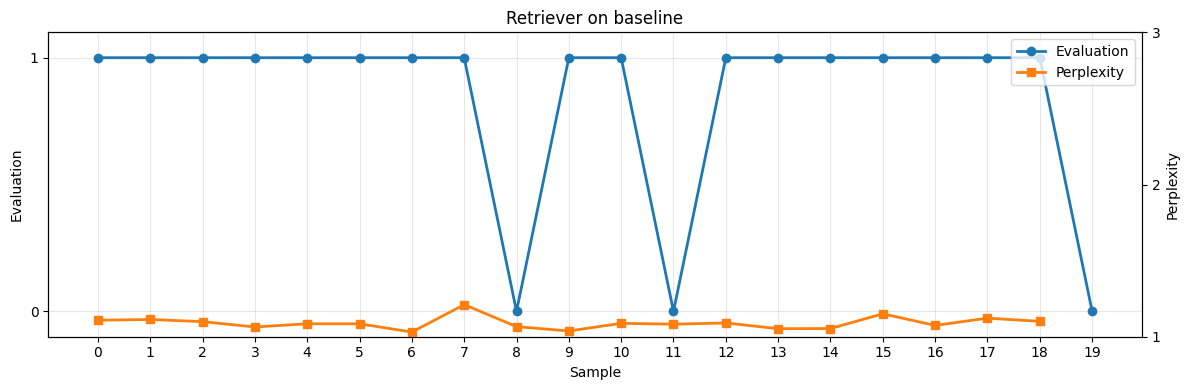

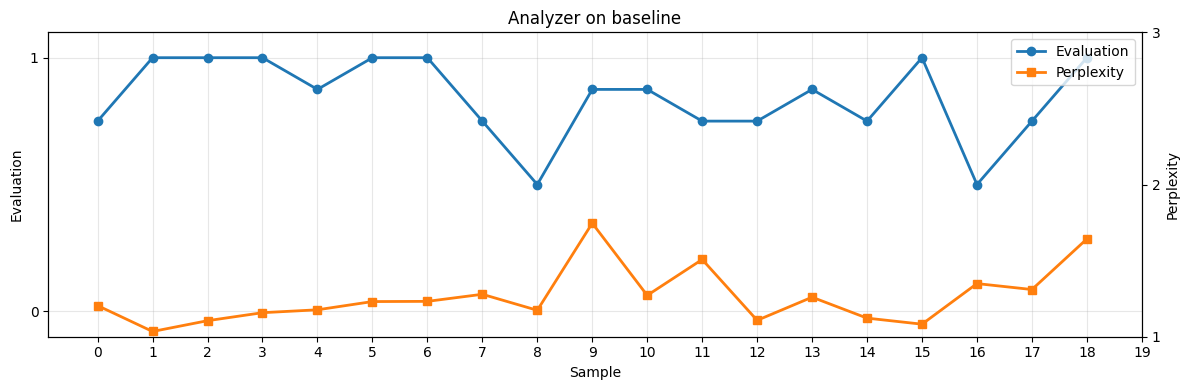

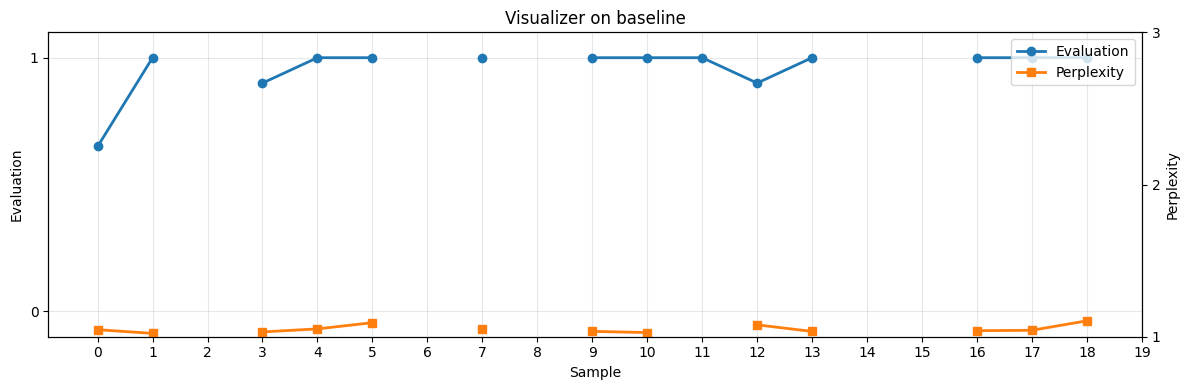

In [98]:
plot_result(baseline_df, "baseline")

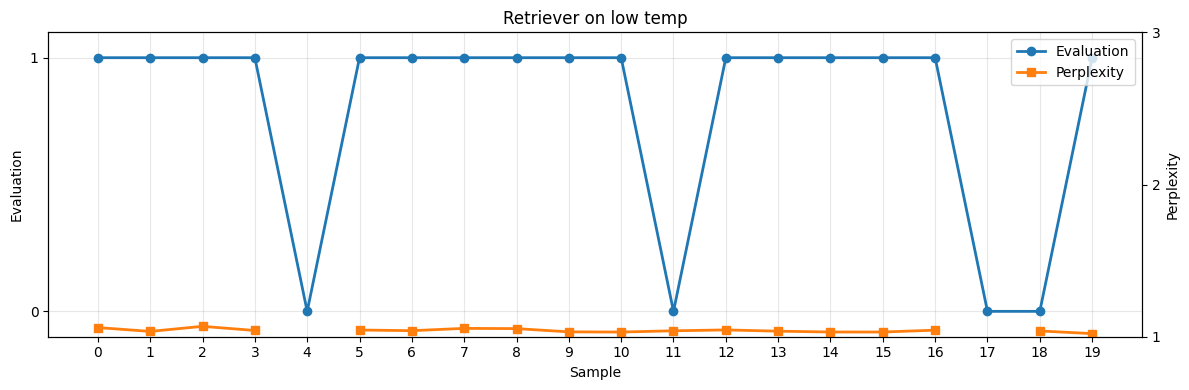

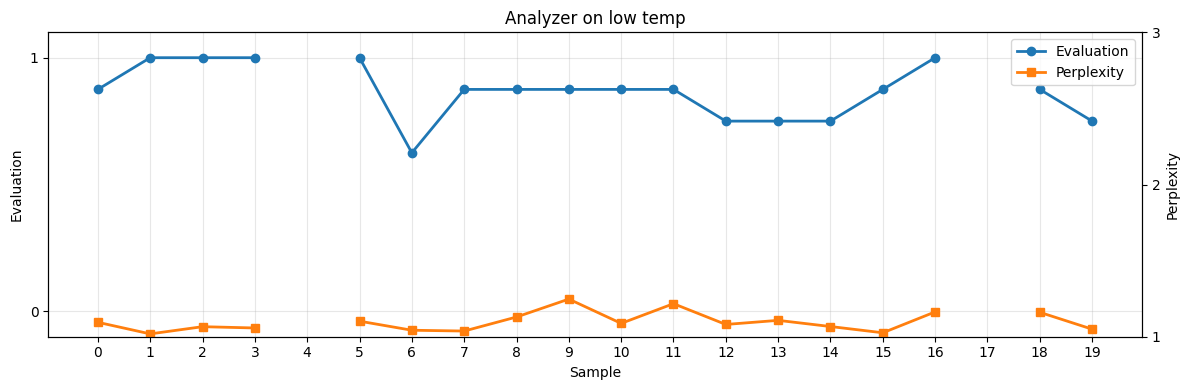

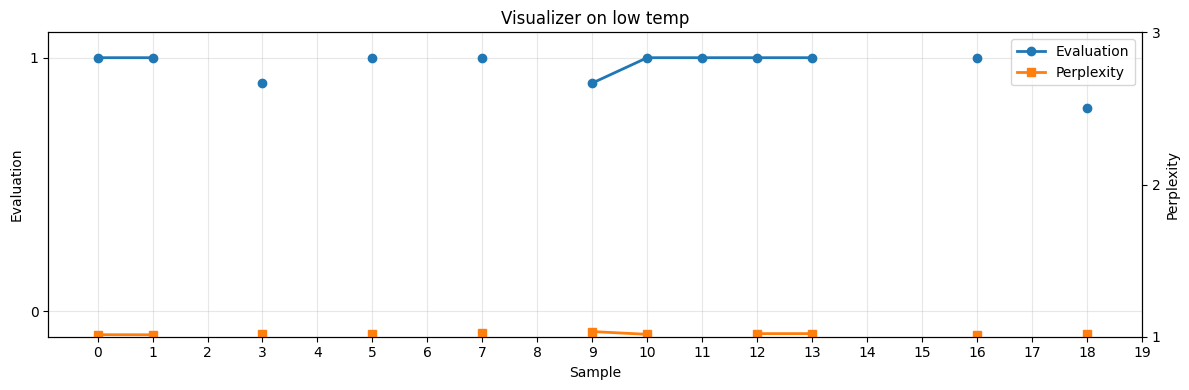

In [99]:
plot_result(low_df, "low temp")

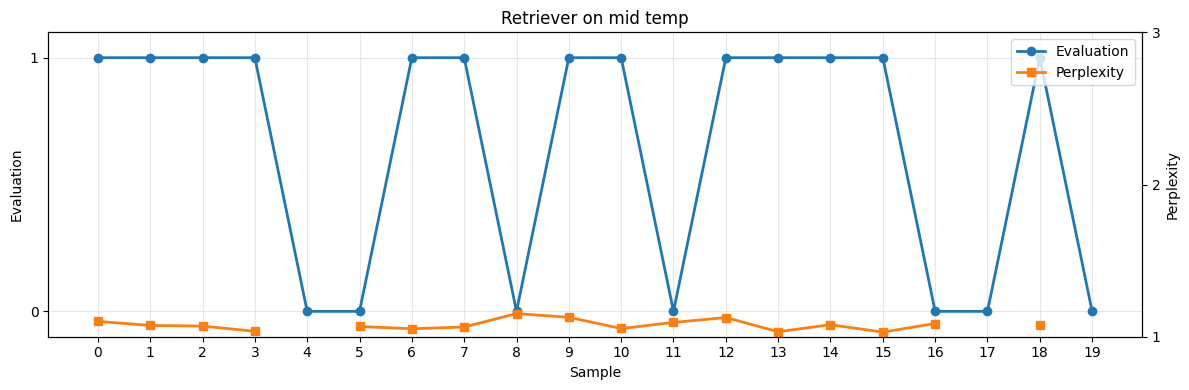

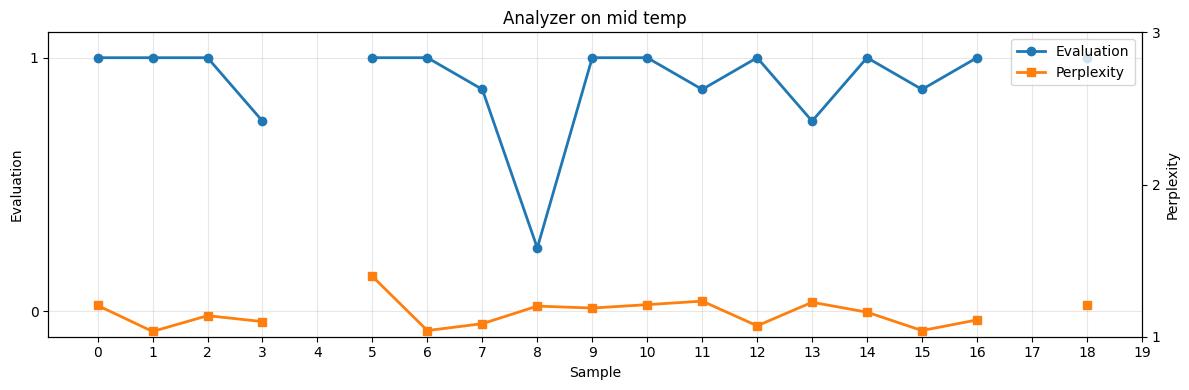

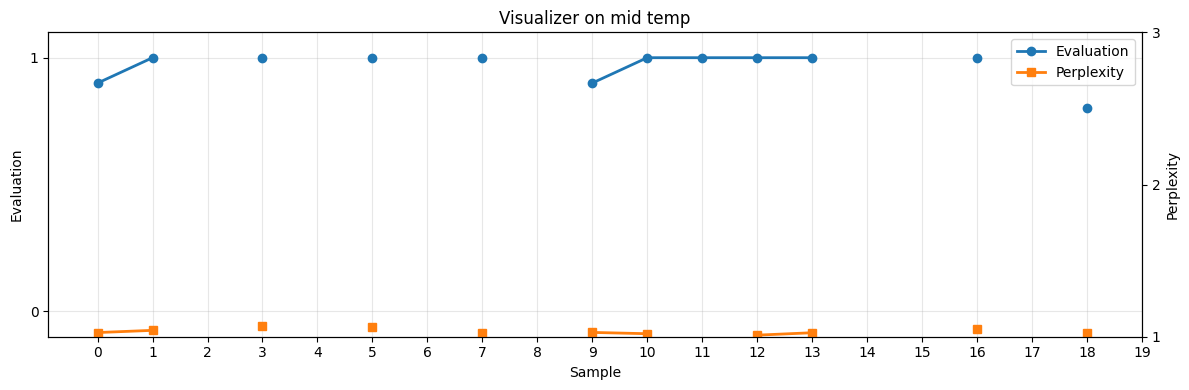

In [100]:
plot_result(mid_df, "mid temp")

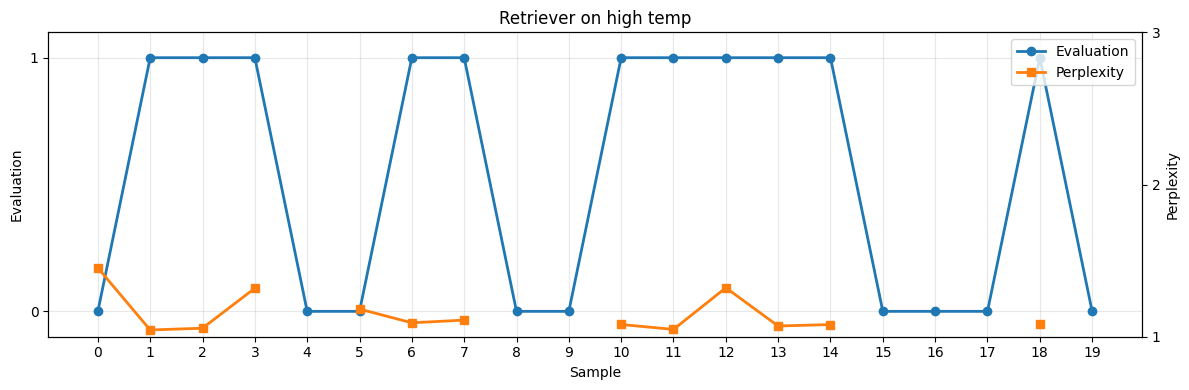

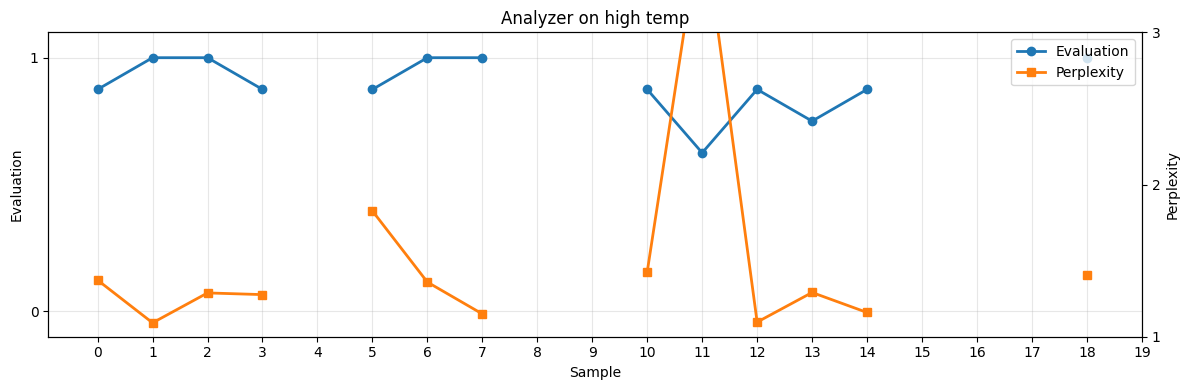

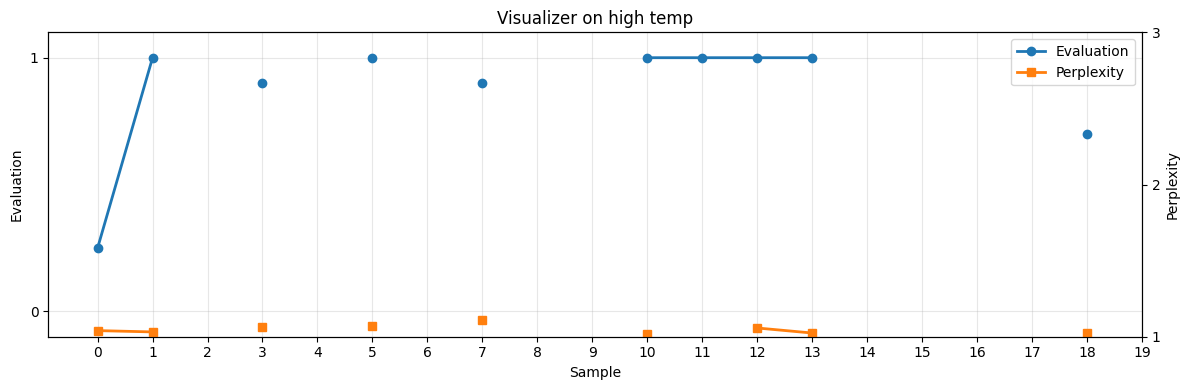

In [101]:
plot_result(high_df, "high temp")

# Overall Results

In [72]:
relevant_columns = [
    "Retriever_1_evaluation_gt",
    "Retriever_1_perplexity",
    "Analyzer_1_evaluation_gt",
    "Analyzer_1_perplexity",
    "Visualizer_1_evaluation_gt",
    "Visualizer_1_perplexity",
]

In [90]:
# Compute averages
summary = pd.DataFrame(
    {
        "baseline": baseline_df[relevant_columns].mean(),
        "low": low_df[relevant_columns].mean(),
        "mid": mid_df[relevant_columns].mean(),
        "high": high_df[relevant_columns].mean(),
    }
).T

display(summary)

,Retriever_1_evaluation_gt,Retriever_1_perplexity,Analyzer_1_evaluation_gt,Analyzer_1_perplexity,Visualizer_1_evaluation_gt,Visualizer_1_perplexity
baseline,0.85,1.090304,0.842105,1.262842,0.960714,1.050361
low,0.80,1.041231,0.868056,1.097475,0.966667,1.019445
mid,0.65,1.077841,0.904412,1.156158,0.966667,1.035093
high,0.55,1.149189,0.894231,1.501868,0.875000,1.048360


In [107]:
def plot_agent_eval_vs_perplexity(summary_df, agent):
    """
    Plot evaluation_gt vs perplexity for one agent.

    summary_df:
        index -> baseline, low, mid, high
        columns -> Agent_1_evaluation_gt, Agent_1_Perplexity, ...
    """

    eval_col = f"{agent}_1_evaluation_gt"
    ppl_col = f"{agent}_1_perplexity"

    plot_df = summary_df[[eval_col, ppl_col]]

    _, ax1 = plt.subplots(figsize=(7, 4))

    (line1,) = ax1.plot(
        plot_df.index,
        plot_df[eval_col],
        marker="o",
        color="tab:blue",
        label="Evaluation GT",
    )
    ax1.set_ylabel("Evaluation GT")
    ax1.set_ylim(0.5, 1)

    ax2 = ax1.twinx()
    (line2,) = ax2.plot(
        plot_df.index,
        plot_df[ppl_col],
        marker="s",
        color="tab:orange",
        label="Perplexity",
    )
    ax2.set_ylabel("Perplexity")
    ax2.set_ylim(1, 2)

    ax1.set_title(f"{agent}: Evaluation vs Perplexity")
    ax1.legend([line1, line2], ["Evaluation GT", "Perplexity"])

    plt.tight_layout()
    plt.show()

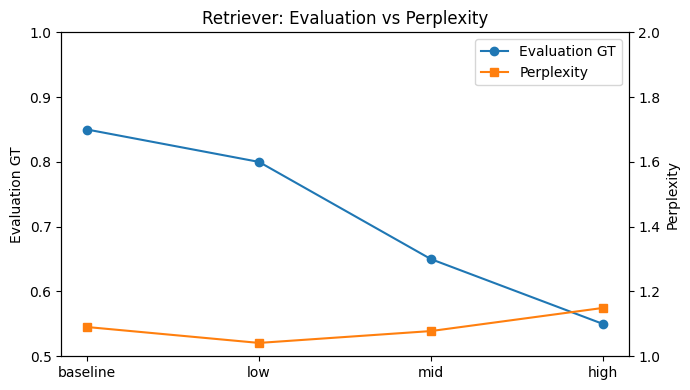

In [108]:
plot_agent_eval_vs_perplexity(summary, "Retriever")

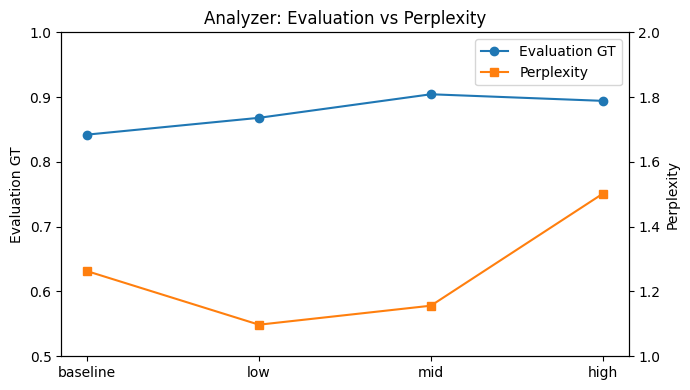

In [109]:
plot_agent_eval_vs_perplexity(summary, "Analyzer")

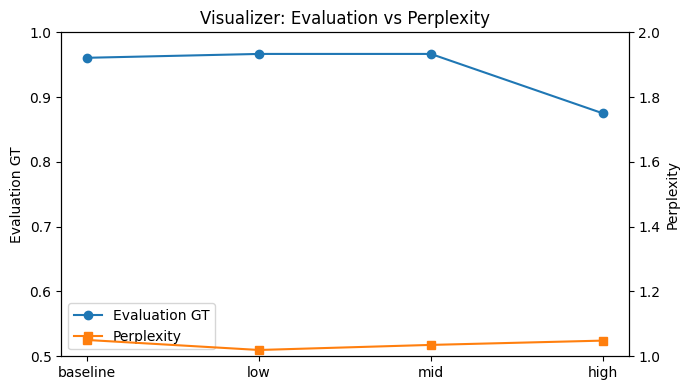

In [110]:
plot_agent_eval_vs_perplexity(summary, "Visualizer")